In [1]:
import warnings

from scipy.linalg import LinAlgWarning
from scipy.sparse import SparseEfficiencyWarning

import pandas as pd

from pandapower.plotting import simple_plot
from pandapower.shortcircuit.calc_sc import calc_sc
from pandapower.create import create_empty_network, create_bus, create_ext_grid, create_transformer3w_from_parameters

warnings.simplefilter("ignore", category=LinAlgWarning)
warnings.simplefilter("ignore", category=SparseEfficiencyWarning)

pd.options.display.float_format = '{:,.5f}'.format

In [2]:
def single_3w_trafo_grid(vector_group, sn_mva=123):
    net = create_empty_network(sn_mva=sn_mva)
    b1 = create_bus(net, vn_kv=380., geodata=(1, 1))
    b2 = create_bus(net, vn_kv=110., geodata=(0, 1))
    b3 = create_bus(net, vn_kv=30., geodata=(1, 0))
    create_ext_grid(net, b1, s_sc_max_mva=1000, s_sc_min_mva=800, rx_max=0.1, x0x_max=1, r0x0_max=0.1, rx_min=0.1,
                    x0x_min=1, r0x0_min=0.1)

    create_transformer3w_from_parameters(net, hv_bus=b1, mv_bus=b2, lv_bus=b3, vn_hv_kv=400, vn_mv_kv=120, vn_lv_kv=30,
                                         sn_hv_mva=350, sn_mv_mva=350, sn_lv_mva=50, pfe_kw=0, i0_percent=0,
                                         vk_hv_percent=21, vkr_hv_percent=.26, vk_mv_percent=7, vkr_mv_percent=.16,
                                         vk_lv_percent=10., vkr_lv_percent=.16, vk0_hv_percent=44.1,
                                         vkr0_hv_percent=0.26, vk0_mv_percent=6.2996, vkr0_mv_percent=0.03714,
                                         vk0_lv_percent=6.2996, vkr0_lv_percent=0.03714, vector_group=vector_group)
    return net

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


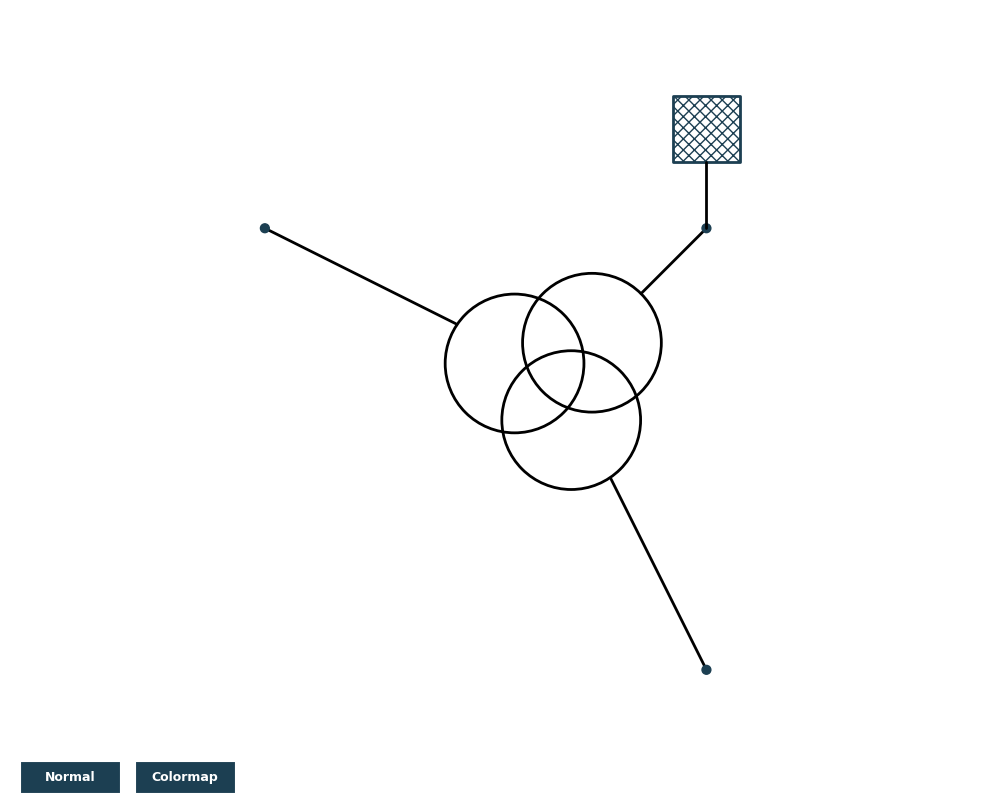

<Axes: >

In [3]:
# beauftragt: Y0y0d5, YN0y0d5, Y0yn0d5, YN0yn0d5, Y0y0y0, Y0d5d5, YN0d5d5, Y0d5y0, Y0y0d11 und D0d0d0 
# implementiert zusätzlich: YNdy, Ydyn, YNdyn, YNyy
vg = "yyy"
net = single_3w_trafo_grid(vg)
simple_plot(net, ext_grid_size=5)

In [4]:
net = single_3w_trafo_grid("Yyy")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [5]:
net = single_3w_trafo_grid("Ydd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [6]:
net = single_3w_trafo_grid("Ddd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [7]:
net = single_3w_trafo_grid("Yynd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,3.33940,0.10727,18.19496,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [8]:
net = single_3w_trafo_grid("Ydyn")  # Extra vector group
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,8.83645,0.00670,1.13718,0.11730,2.66335


In [9]:
net = single_3w_trafo_grid("YNynd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171
1,3.49934,0.21021,15.31723,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [10]:
net = single_3w_trafo_grid("YNdyn")  # Extra vector group
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.79376,4.86639,85.86380,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,9.04239,0.01219,0.98955,0.11730,2.66335


In [11]:
net = single_3w_trafo_grid("YNyd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [12]:

net = single_3w_trafo_grid("YNdy")  # Extra vector group
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.79376,4.86639,85.86380,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [13]:

net = single_3w_trafo_grid("YNdd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.84354,3.76841,75.01993,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [14]:
net = single_3w_trafo_grid("YNyy")  # Extra vector group
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc  # warum dasselbe Ergebnis wie Yyy?

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


# Single-bus fault

all-bus fault vs single-bus fault vs LU factorization

## Ynynd

In [15]:
net = single_3w_trafo_grid("Ynynd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171
1,3.49934,0.21021,15.31723,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [16]:
net = single_3w_trafo_grid("Ynynd")
calc_sc(net, fault="1ph", case="max", bus=0)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171


In [17]:
# now with LU factorization instead of Y inversion
net = single_3w_trafo_grid("Ynynd")  
calc_sc(net, fault="1ph", case="max", bus=0, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171


In [18]:
# now with LU factorization instead of Y inversion
net = single_3w_trafo_grid("Ynynd")  
calc_sc(net, fault="1ph", case="max", bus=1, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
1,3.49934,0.21021,15.31723,1.52174,22.24258


In [19]:
# now with LU factorization instead of Y inversion
net = single_3w_trafo_grid("Ynynd")  
calc_sc(net, fault="1ph", case="max", bus=2, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
2,0.00000,inf,inf,0.11730,2.66335


## Ydd

In [20]:
net = single_3w_trafo_grid("Ydd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [21]:
net = single_3w_trafo_grid("Ydd")
calc_sc(net, fault="1ph", case="max", bus=0, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.51934,15.80517,158.05171,15.80517,158.05171


In [22]:
net = single_3w_trafo_grid("Ydd")
calc_sc(net, fault="1ph", case="max", bus=1, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
1,0.00000,inf,inf,1.52174,22.24258


In [23]:
net = single_3w_trafo_grid("Ydd")
calc_sc(net, fault="1ph", case="max", bus=2, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
2,0.00000,inf,inf,0.11730,2.66335


## YNyd

In [24]:
net = single_3w_trafo_grid("YNyd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [25]:
net = single_3w_trafo_grid("YNyd")
calc_sc(net, fault="1ph", case="max", bus=0, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.78326,5.12452,88.22838,15.80517,158.05171


In [26]:
net = single_3w_trafo_grid("YNyd")
calc_sc(net, fault="1ph", case="max", bus=1, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
1,0.00000,inf,inf,1.52174,22.24258


In [27]:
net = single_3w_trafo_grid("YNyd")
calc_sc(net, fault="1ph", case="max", bus=2, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
2,0.00000,inf,inf,0.11730,2.66335


## YNdd

In [28]:
net = single_3w_trafo_grid("YNdd")
calc_sc(net, fault="1ph", case="max")
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.84354,3.76841,75.01993,15.80517,158.05171
1,0.00000,inf,inf,1.52174,22.24258
2,0.00000,inf,inf,0.11730,2.66335


In [29]:
net = single_3w_trafo_grid("YNdd")
calc_sc(net, fault="1ph", case="max", bus=0, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
0,1.84354,3.76841,75.01993,15.80517,158.05171


In [30]:
net = single_3w_trafo_grid("YNdd")
calc_sc(net, fault="1ph", case="max", bus=1, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
1,0.00000,inf,inf,1.52174,22.24258


In [31]:
net = single_3w_trafo_grid("YNdd")
calc_sc(net, fault="1ph", case="max", bus=2, inverse_y=False)
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,rk_ohm,xk_ohm
2,0.00000,inf,inf,0.11730,2.66335


For further vector groups, we included the check in the test, all the vector groups passed.